In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
#read our csv files
df = pd.read_csv('engineering_sensor_data.csv')

In [3]:
#check data type on our dataframe
print(df.dtypes)


Sensor_ID          object
Temperature_C     float64
Pressure_psi      float64
Vibration_mm_s    float64
RPM                 int64
Status             object
Timestamp          object
dtype: object


In [4]:
print(df)

    Sensor_ID  Temperature_C  Pressure_psi  Vibration_mm_s   RPM   Status  \
0          S4          74.55        182.93            2.75  4577  Warning   
1          S5          77.17        199.71            2.40  3901       OK   
2          S3          80.12        204.04            2.40  2387       OK   
3          S5          80.43        183.91            1.36  2303       OK   
4          S5          75.28        171.19            2.90  1592  Warning   
..        ...            ...           ...             ...   ...      ...   
195        S3          66.57        177.28            3.01  1249  Warning   
196        S3          78.92        204.52            2.19  1390  Warning   
197        S1          73.75        216.79            3.13  4853       OK   
198        S5          73.00        199.78            2.32  1334       OK   
199        S4          95.25        167.24            2.74  1628  Warning   

               Timestamp  
0    2025-01-01 00:00:00  
1    2025-01-01 01:00


Question 2

Line chart - Temperature Trend Over Time
plot the average temperature over time using plt.plot()
X-axis:Timestamp
Y-axis:Temperature_C

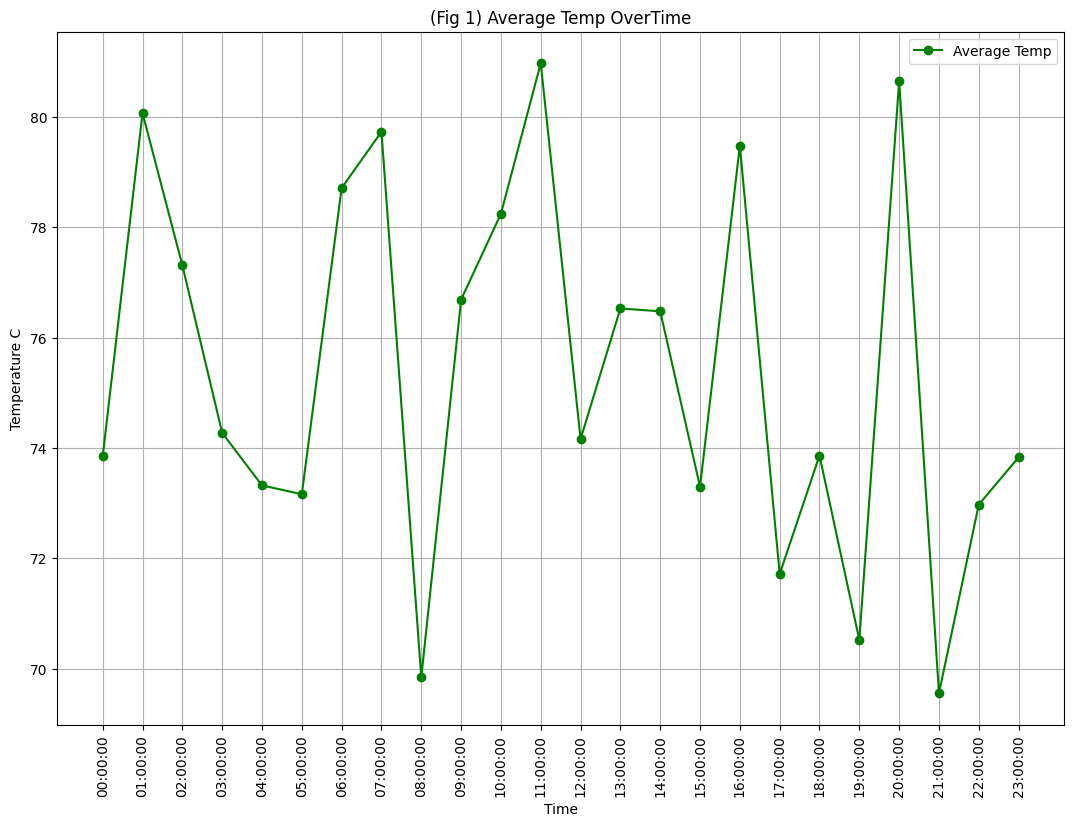

In [ ]:

#since our time stamp was object lets convert it for datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

#lets out outer for our time for easy 
df['Time'] = df['Timestamp'].dt.strftime('%H:%M:%S')

plt.figure(figsize=(13, 9))  # the size of  our figure 

# get the mean of temperature per time
mean_temp = df.groupby('Time')['Temperature_C'].mean()

#average temperature Over time

#lets group the average temp per time and reset its index
mean_temp = df.groupby('Time')['Temperature_C'].mean().reset_index()

#and rename each columns
mean_temp.columns = ['Time','Temperature_C']


plt.plot(mean_temp['Time'],mean_temp['Temperature_C'], marker='o', linestyle='-', color='green', label="Average Temp")
plt.xlabel('Time')
plt.ylabel('Temperature C')
plt.title('(Fig 1) Average Temp OverTime')
plt.xticks(rotation=90)

plt.legend()
plt.grid()
plt.savefig("2q_average_temp_time.png")
plt.show()


In [8]:
print(mean_temp.nlargest(3,'Temperature_C'))
# the highest Peak for  was on 11:00 am, 20:00 pm and 01:00 am 

        Time  Temperature_C
11  11:00:00      80.972500
20  20:00:00      80.648750
1   01:00:00      80.068889


In [9]:
print(mean_temp.nsmallest(3,'Temperature_C'))
# the lowest Peak was on 21:00 pm, 8:00 am and 19:00 pm

        Time  Temperature_C
21  21:00:00       69.55625
8   08:00:00       69.84250
19  19:00:00       70.52000


In [10]:
print(mean_temp['Temperature_C'].describe())
print('Conclusion here was there was 24 sample here like 24 hours on our time')
print('The average temperature we get was 75.38 Celcius')
print('The temperature was range on 69.55 c to 80.97 c')
print('The temperature standard deviation was around 3.45')


count    24.000000
mean     75.384439
std       3.455731
min      69.556250
25%      73.262743
50%      74.217847
75%      78.360590
max      80.972500
Name: Temperature_C, dtype: float64
Conclusion here was there was 24 sample here like 24 hours on our time
The average temperature we get was 75.38 Celcius
The temperature was range on 69.55 c to 80.97 c
The temperature standard deviation was around 3.45


Question 3

Scatter Plot - Vibration vs RPM
Plot vibration level against RPM using plt.scatter()
X-axis:RPM
Y-axis:Vibration_mm_s
Use color to represent Status(OK,Warning,Failure)

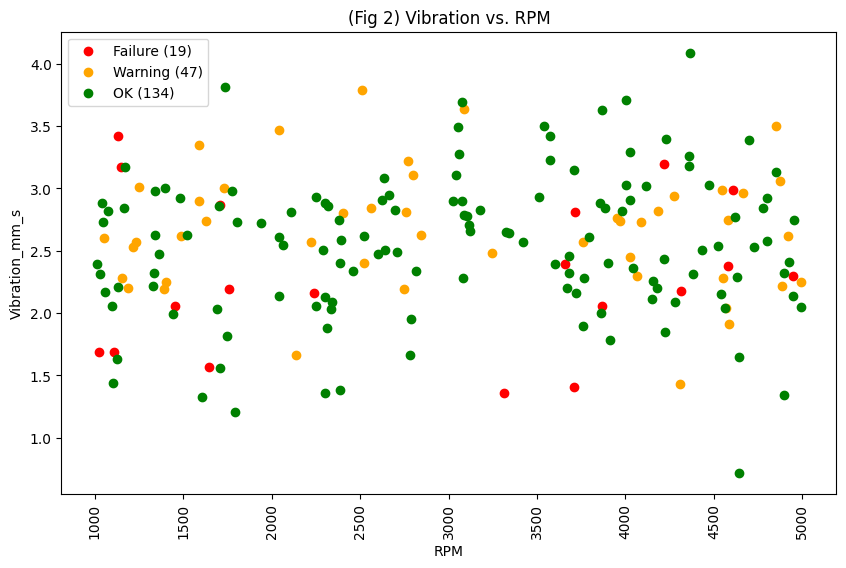

In [11]:

plt.figure(figsize=(10, 6))  # the size of  our figure 

status_count = df['Status'].value_counts()

# get the value of each Status
ok_count = status_count.get('OK',0)
failure_count = status_count.get('Failure',0)
warning_count = status_count.get('Warning',0)

#dictionary 
counts_dict = ({'OK': ok_count, 'Failure': failure_count, 'Warning': warning_count})

#sort the dictionary ascending

sort_status = sorted(counts_dict.items(),key=lambda x: x[1])

#color for label
color_status ={
    'OK':'green',
    'Failure':'red',
    "Warning":"orange"
}

for status,count in sort_status:
    subset = df[df['Status'] == status]
    label_text = f"{status} ({count})"
    plt.scatter(subset['RPM'],subset['Vibration_mm_s'],label = label_text,color=color_status.get(status,'grey') )


plt.xlabel('RPM')
plt.ylabel('Vibration_mm_s')
plt.title('(Fig 2) Vibration vs. RPM')
plt.xticks(rotation=90)

plt.legend()
plt.savefig("3q_vibration_vs_rpm.png")
plt.show()




In [12]:
#get rpm per status
status_rpm_largest = df.groupby('Status')['RPM'].nlargest(1)
status_rpm_lowest = df.groupby('Status')['RPM'].nsmallest(1)

#get Vibration_mm_s per status
status_vibration_nlargest = df.groupby('Status')['Vibration_mm_s'].nlargest(1)
status_vibration_lowest = df.groupby('Status')['Vibration_mm_s'].nsmallest(1)

print(f'RPM Peak was {status_rpm_largest}')
print('----------------------------------------------------------------------------------------------------------------------------------------')
print(f'RPM Lowest was {status_rpm_lowest}')
print('----------------------------------------------------------------------------------------------------------------------------------------')
print(f'Vibration peak was {status_vibration_nlargest}')
print('----------------------------------------------------------------------------------------------------------------------------------------')
print(f'Vibration lowest was {status_vibration_lowest}')
print('----------------------------------------------------------------------------------------------------------------------------------------')
print(f'Failure appears {failure_count}, Warning appears also {warning_count}, while ok count appear at most {ok_count}')
print(f'When interpret the data, it appears that when vibration is on the lower end (below 2.0)')
print(f"the counts are: Warning - 5, Failure - 2, and OK - 11")

RPM Peak was Status      
Failure  53     4945
OK       181    4993
Warning  191    4990
Name: RPM, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------
RPM Lowest was Status      
Failure  137    1024
OK       161    1011
Warning  101    1054
Name: RPM, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------
Vibration peak was Status      
Failure  77     3.42
OK       84     4.09
Warning  170    3.79
Name: Vibration_mm_s, dtype: float64
----------------------------------------------------------------------------------------------------------------------------------------
Vibration lowest was Status      
Failure  62     1.36
OK       157    0.72
Warning  25     1.43
Name: Vibration_mm_s, dtype: float64
-----------------------------------------------------------------------------------------------




Question 4
Bar Chart - Average Pressure per Sensor
Use plt.bar() to compare the average pressure of each Sensor_ID

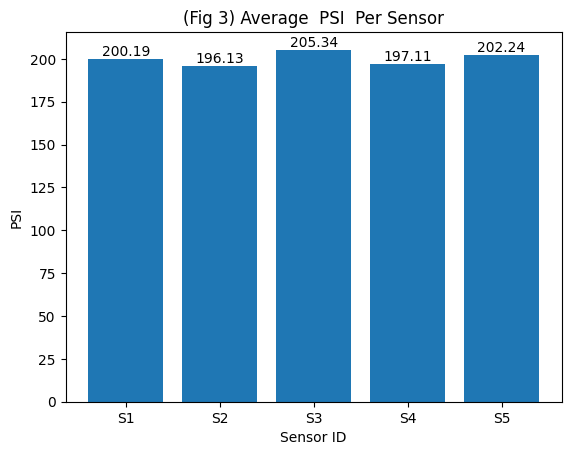

In [13]:
# get temperature average per sensor
mean_psi_sensor = df.groupby('Sensor_ID')['Pressure_psi'].mean().reset_index()

#rename the column
mean_psi_sensor.columns = ['Sensor_ID','Pressure_psi']

plt.bar(mean_psi_sensor['Sensor_ID'],mean_psi_sensor['Pressure_psi'])
plt.xlabel('Sensor ID')
plt.ylabel('PSI')
plt.title('(Fig 3) Average  PSI  Per Sensor')

#get the value of sensor
for index, value in enumerate(mean_psi_sensor['Pressure_psi']):
    plt.text(mean_psi_sensor['Sensor_ID'][index], value, f'{value:.2f}', ha='center', va='bottom')
 
plt.savefig("4q_psi_per_sensor.png")
plt.show()




In [14]:
print(mean_psi_sensor['Pressure_psi'].describe())
print('The mean of psi pressure was around 200.201757')
print('We have 5 data in here as stated as count')
print('----------------------------------------------------------------------------------------------------------------------------------------')
print(f"When I checked the average pressure per sensor, the peak was {mean_psi_sensor['Pressure_psi'].nlargest(1).values[0]:.2f} PSI.")
print(f"The lowest pressure per sensor was {mean_psi_sensor['Pressure_psi'].nsmallest(1).values[0]:.2f} PSI.")


count      5.000000
mean     200.201757
std        3.765403
min      196.130000
25%      197.105510
50%      200.194651
75%      202.239167
max      205.339459
Name: Pressure_psi, dtype: float64
The mean of psi pressure was around 200.201757
We have 5 data in here as stated as count
----------------------------------------------------------------------------------------------------------------------------------------
When I checked the average pressure per sensor, the peak was 205.34 PSI.
The lowest pressure per sensor was 196.13 PSI.


Question 5

Horizontal Bar Chart - Failure Counts by Sensor
Count how many times each sensor had a status of 'Failure' and use plt.barh() to the plot the result

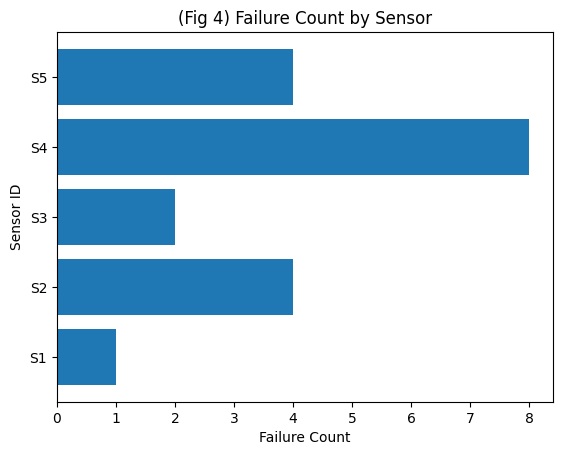

In [15]:
sensor_failure_count = df[df['Status']=='Failure'].groupby('Sensor_ID').size().reset_index()

sensor_failure_count.columns = ['Sensor_ID','Failure_Count']

plt.barh(sensor_failure_count['Sensor_ID'],sensor_failure_count['Failure_Count'])
plt.xlabel('Failure Count')
plt.ylabel('Sensor ID')
plt.title("(Fig 4) Failure Count by Sensor")


plt.savefig("5q_failure_count_per_sensor.png")
plt.show()



In [16]:
print('When we check the failure count it appear that sensor S4 appear most Failure Count')
print('The least was Sensor S1, least failure Count')
print('It seems that failure count was no correlation into PSI alone on Figure 3')
print('Safe to Pressure alone was not evidence that sensor fail')

When we check the failure count it appear that sensor S4 appear most Failure Count
The least was Sensor S1, least failure Count
It seems that failure count was no correlation into PSI alone on Figure 3
Safe to Pressure alone was not evidence that sensor fail


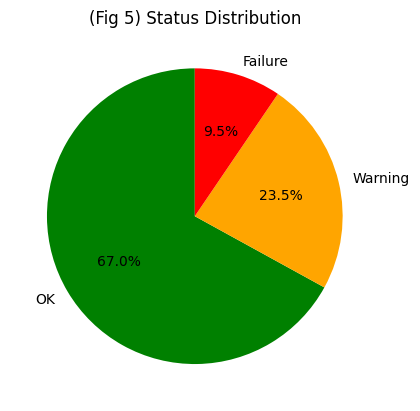

In [17]:
# get the number of status 
status_count = df['Status'].value_counts()

#color for label
color_status ={
    'OK':'green',
    'Failure':'red',
    "Warning":"orange"
}

# plot pie chart with labels
colors = [color_status.get(s, 'grey') for s in status_count.index]
plt.pie(status_count, labels=status_count.index, autopct='%1.1f%%', colors=colors, startangle=90)

plt.title('(Fig 5) Status Distribution')
plt.savefig("6q_status_distribution.png")
plt.show()






In [18]:

print('We can conclude that Status distribution was the most is OK with 67%, Warning 23.5% while Failure 9.5%')
print('----------------------------------------------------------------------------------------------------------------------------------------')
mean_temp_per_status = df.groupby("Status")['Temperature_C'].mean()
print(mean_temp_per_status)
print('It seems there is no corellation failure of sensor into Temperature')
print('----------------------------------------------------------------------------------------------------------------------------------------')
mean_rpm_per_status = df.groupby("Status")['RPM'].mean()

print(mean_rpm_per_status)
print('It look like average of Failure of Sensor when RPM WAS 2849 of sensor into RPM')
print('----------------------------------------------------------------------------------------------------------------------------------------')

mean_vib_per_status = df.groupby('Status')['Vibration_mm_s'].mean()
print(mean_vib_per_status)
print('It look like average of Failure of Sensor when Vibration WAS 2.31 of sensor into Vibration_mm_s')
print('----------------------------------------------------------------------------------------------------------------------------------------')
mean_psi_per_status = df.groupby('Status')['Pressure_psi'].mean()
print(mean_psi_per_status)
print('It look like average of Failure of Sensor when PSI WAS 198.473158 of sensor into Pressure_psi')
print('----------------------------------------------------------------------------------------------------------------------------------------')


print('My conclusion into those 3 Variable  when it was the lowest value it always on failure.')
print('When it was on the highest value it awalys fall into Warning')
print("My conclusion into temperature was look like correct before it go to failure to warnign there was")
print('.18 celciu in between')

We can conclude that Status distribution was the most is OK with 67%, Warning 23.5% while Failure 9.5%
----------------------------------------------------------------------------------------------------------------------------------------
Status
Failure    75.702632
OK         75.217985
Warning    75.886809
Name: Temperature_C, dtype: float64
It seems there is no corellation failure of sensor into Temperature
----------------------------------------------------------------------------------------------------------------------------------------
Status
Failure    2849.473684
OK         3046.402985
Warning    3047.000000
Name: RPM, dtype: float64
It look like average of Failure of Sensor when RPM WAS 2849 of sensor into RPM
----------------------------------------------------------------------------------------------------------------------------------------
Status
Failure    2.310526
OK         2.542910
Warning    2.663191
Name: Vibration_mm_s, dtype: float64
It look like average of Fai